In [ ]:
import os

os.chdir(r'C:\Users\zkx14\Desktop\testing')
print('Working directory:', os.getcwd())

# create output folders 
os.makedirs(r'Osteo_PR_Dataset_Cropped\C1_cropped', exist_ok=True)
os.makedirs(r'Osteo_PR_Dataset_Cropped\C3_cropped', exist_ok=True)
print('Output folders ready')
print('  Osteo_PR_Dataset_Cropped/C1_cropped/')
print('  Osteo_PR_Dataset_Cropped/C3_cropped/')

Working directory: C:\Users\zkx14\Desktop\testing
Output folders ready
  Osteo_PR_Dataset_Cropped/C1_cropped/
  Osteo_PR_Dataset_Cropped/C3_cropped/


In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

# Build the same DeepLabV3+ architecture we used for training.
# We don't load imagenet weights here because the checkpoint already contains our trained parameters.
model = smp.DeepLabV3Plus(
    encoder_name    = 'efficientnet-b4',
    encoder_weights = None,
    in_channels     = 3,
    classes         = 1,
    activation      = None
).to(device)

model.load_state_dict(torch.load('models/deeplabv3plus_efficientb4.pth',
    map_location=device
))

model.eval()
print('Model loaded successfully')

Using: cuda
Model loaded successfully


In [ ]:
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path

transform = A.Compose([
    A.Resize(512, 1024),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


def crop_jaw(image_path, out_path, padding=20, threshold=0.5):
    """
    Runs DeepLabV3+ on one X-ray, finds the mandible bounding box,
    crops the jaw region, and saves it to out_path.

    Returns True if successful, False if no mandible was found.
    """

    # load
    img     = cv2.imread(str(image_path))
    if img is None:
        print(f'Could not read: {image_path.name}')
        return False

    img_rgb        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    orig_h, orig_w = img_rgb.shape[:2]

    # run model
    tensor = transform(image=img_rgb)['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = model(tensor)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()

    # binary mask at original resolution
    mask_small = (prob > threshold).astype(np.uint8) # 0 or 1 at 512x1024
    mask_full  = cv2.resize(mask_small, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # bounding box
    coords = cv2.findNonZero(mask_full)
    if coords is None:
        print(f'No mandible found: {image_path.name}')
        return False
    
    # apply mask to original image to remove noise outside the jaw
    # expand mask to 3 channels so it works on RGB
    mask_3ch = np.stack([mask_full]*3, axis=-1)
    masked_img = (img_rgb * mask_3ch).astype(np.uint8) 

    x, y, w, h = cv2.boundingRect(coords)

    x, y, w, h = cv2.boundingRect(coords)
    x1 = max(x - 20, 0)
    y1 = max(y - 20, 0)
    x2 = min(x + w + 20, orig_w)
    y2 = min(y + h + 20, orig_h)

    jaw_crop = masked_img[y1:y2, x1:x2]

    cv2.imwrite(str(out_path), cv2.cvtColor(jaw_crop, cv2.COLOR_RGB2BGR))
    return True


print('Function ready')

Function ready


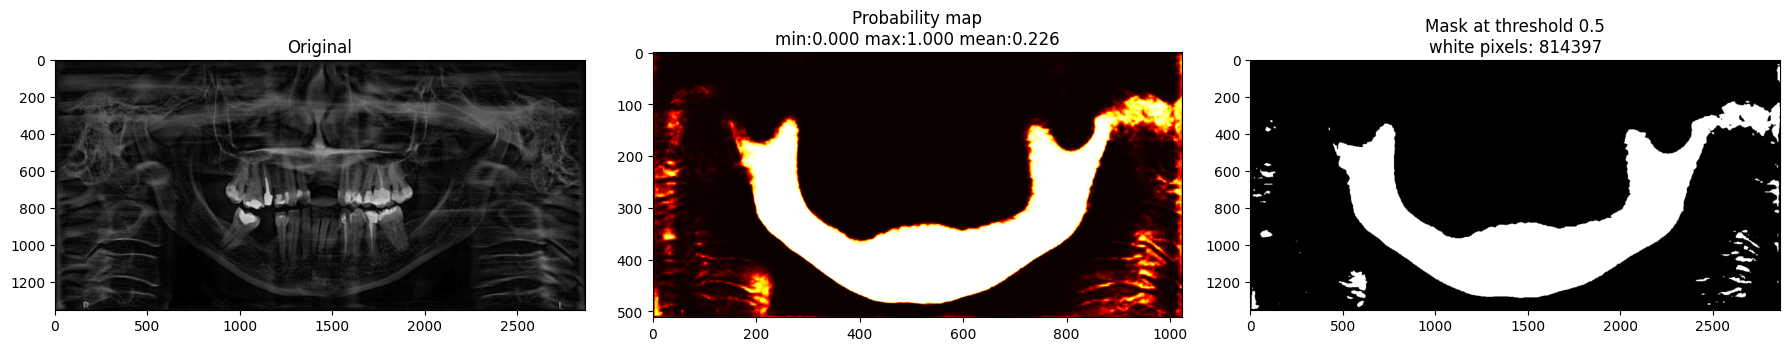

Image size: 2863x1348
Prob range: 0.0000 to 1.0000


In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch
from pathlib import Path
from albumentations.pytorch import ToTensorV2
import albumentations as A

# quick sanity check on a single image before we batch-process everything
# swap this path if you want to test a different X-ray
test_image = r'Osteo_PR_Dataset\OP_Rolling_Ball_Imgs\C1\OPHUB2015-0079.jpg'

img = cv2.imread(test_image)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
orig_h, orig_w = img_rgb.shape[:2]

transform = A.Compose([
    A.Resize(512, 1024),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

tensor = transform(image=img_rgb)['image'].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(tensor)
    prob   = torch.sigmoid(logits).squeeze().cpu().numpy()

# visualize the model output so we can see if it's actually focusing on the jaw
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_rgb)
axes[0].set_title('Original X-ray')

axes[1].imshow(prob, cmap='hot')
axes[1].set_title(f'Probability map\nmin:{prob.min():.3f} max:{prob.max():.3f} mean:{prob.mean():.3f}')

mask = (prob > 0.5).astype(np.uint8) * 255
mask = cv2.resize(mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
axes[2].imshow(mask, cmap='gray')
axes[2].set_title(f'Mask at threshold 0.5\nwhite pixels: {(mask>0).sum()}')

plt.tight_layout()
plt.show()

print(f'Image size: {orig_w}x{orig_h}')
print(f'Prob range: {prob.min():.4f} to {prob.max():.4f}')

In [ ]:
# ── Process both C1 and C3 folders ────────────────────────────────────────

FOLDERS = {
    r'Osteo_PR_Dataset\OP_Rolling_Ball_Imgs\C1': r'Osteo_PR_Dataset_Cropped\C1_cropped',
    r'Osteo_PR_Dataset\OP_Rolling_Ball_Imgs\C3': r'Osteo_PR_Dataset_Cropped\C3_cropped',
}

for input_folder, output_folder in FOLDERS.items():

    input_dir  = Path(input_folder)
    output_dir = Path(output_folder)

    # collect common image formats, since the dataset has mixed file types
    images = list(input_dir.glob('*.jpg')) + \
             list(input_dir.glob('*.png')) + \
             list(input_dir.glob('*.jpeg'))

    print(f'\n{input_folder}  →  {output_folder}')
    print(f'Found {len(images)} images')
    print('-' * 50)

    success = 0
    failed  = 0

    for img_path in images:
        out_path = output_dir / img_path.name   # keep original filename for traceability
        ok       = crop_jaw(img_path, out_path)

        if ok:
            success += 1
            print(f'{img_path.name}')
        else:
            failed += 1

    print(f'\n  Done: {success} saved, {failed} failed')


print('\n=============================')
print('All folders processed')


Osteo_PR_Dataset\OP_Rolling_Ball_Imgs\C1  →  Osteo_PR_Dataset_Cropped\C1_cropped
Found 304 images
--------------------------------------------------
OPHUB2015-0007.jpg
OPHUB2015-0013.jpg
OPHUB2015-0028.jpg
OPHUB2015-0072.jpg
OPHUB2015-0077.jpg
OPHUB2015-0079.jpg
OPHUB2017-0001.jpg
OPHUB2017-0008.jpg
OPHUB2017-0045.jpg
OPHUB2017-0062.jpg
OPHUB2017-0092.jpg
OPHUB2017-0192.jpg
OPHUB2017-0206.jpg
OPHUB2018-0014.jpg
OPHUB2018-0027.jpg
OPHUB2018-0042.jpg
OPHUB2018-0064.jpg
OPHUB2018-0086.jpg
OPHUB2018-0089.jpg
OPHUB2018-0093.jpg
OPHUB2018-0105.jpg
OPHUB2018-0126.jpg
OPHUB2018-0166.jpg
OPHUB2018-0172.jpg
OPHUB2018-0176.jpg
OPHUB2018-0199.jpg
OPHUB2018-0202.jpg
OPHUB2018-0227.jpg
OPHUB2018-0249.jpg
OPHUB2018-0291.jpg
OPHUB2018-0318.jpg
OPHUB2018-0319.jpg
OPHUB2018-0326.jpg
OPHUB2018-0330.jpg
OPHUB2018-0342.jpg
OPHUB2018-0351.jpg
OPHUB2018-0355.jpg
OPHUB2018-0406.jpg
OPHUB2018-0433.jpg
OPHUB2018-0470.jpg
OPHUB2018-0477.jpg
OPHUB2018-0483.jpg
OPHUB2018-0490.jpg
OPHUB2018-0506.jpg
OPHUB2018-0514